In [3]:
# import the necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns

In [86]:
# load the data
data = pd.read_csv('/content/companies.csv')

#1.Explore the data set

In [73]:
data.info() # View data types and non-null counts of each column.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196553 entries, 0 to 196552
Data columns (total 44 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   196553 non-null  object 
 1   Unnamed: 0.1         196553 non-null  int64  
 2   entity_type          196553 non-null  object 
 3   entity_id            196553 non-null  int64  
 4   parent_id            0 non-null       float64
 5   name                 196530 non-null  object 
 6   normalized_name      196527 non-null  object 
 7   permalink            196553 non-null  object 
 8   category_code        123186 non-null  object 
 9   status               196553 non-null  object 
 10  founded_at           91227 non-null   object 
 11  closed_at            2620 non-null    object 
 12  domain               126545 non-null  object 
 13  homepage_url         126545 non-null  object 
 14  twitter_username     80591 non-null   object 
 15  logo_url         

In [75]:
data.head() # Display the first few rows of the dataset.

,id,Unnamed: 0.1,entity_type,entity_id,parent_id,name,normalized_name,permalink,category_code,status,...,first_milestone_at,last_milestone_at,milestones,relationships,created_by,created_at,updated_at,lat,lng,ROI
0,c:1,0,Company,1,NaN,Wetpaint,wetpaint,/company/wetpaint,web,operating,...,2010-09-05,2013-09-18,5.0,17.0,initial-importer,2007-05-25 06:51:27,2013-04-13 03:29:00,47.606209,-122.332071,15.5
1,c:10,1,Company,10,NaN,Flektor,flektor,/company/flektor,games_video,acquired,...,NaN,NaN,NaN,6.0,initial-importer,2007-05-31 21:11:51,2008-05-23 23:23:14,34.021122,-118.396467,NaN
2,c:100,2,Company,100,NaN,There,there,/company/there,games_video,acquired,...,2003-02-01,2011-09-23,4.0,12.0,initial-importer,2007-08-06 23:52:45,2013-11-04 02:09:48,37.562992,-122.325525,NaN
3,c:10000,3,Company,10000,NaN,MYWEBBO,mywebbo,/company/mywebbo,network_hosting,operating,...,NaN,NaN,NaN,NaN,NaN,2008-08-24 16:51:57,2008-09-06 14:19:18,NaN,NaN,NaN
4,c:10001,4,Company,10001,NaN,THE Movie Streamer,the movie streamer,/company/the-movie-streamer,games_video,operating,...,NaN,NaN,NaN,NaN,NaN,2008-08-24 17:10:34,2008-09-06 14:19:18,NaN,NaN,NaN


In [67]:
data.describe() # Get summary statistics for numerical columns (mean, median, quartiles, etc.).

,Unnamed: 0.1,entity_id,parent_id,logo_width,logo_height,investment_rounds,invested_companies,funding_rounds,funding_total_usd,milestones,relationships,lat,lng,ROI
count,196553.000000,196553.000000,0.0,110110.000000,110110.000000,2591.000000,2591.000000,31707.000000,2.787400e+04,91699.000000,129667.000000,83852.000000,83852.000000,726.000000
mean,98276.000000,153006.227333,NaN,459.132685,222.728917,2.372057,2.204940,1.659760,1.481652e+07,1.199402,2.852067,37.564512,-52.123066,45.745037
std,56740.108067,90209.250941,NaN,594.982577,333.090722,12.173510,11.436955,1.201666,6.775937e+07,0.540099,9.100309,15.477102,70.049067,572.035638
min,0.000000,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,2.910000e+02,1.000000,1.000000,-50.942326,-159.497746,0.011111
25%,49138.000000,59850.000000,NaN,192.000000,70.000000,1.000000,1.000000,1.000000,5.000000e+05,1.000000,1.000000,34.052234,-111.940005,2.648879
50%,98276.000000,174539.000000,NaN,267.000000,105.000000,1.000000,1.000000,1.000000,2.564500e+06,1.000000,1.000000,39.768403,-77.036871,6.500497
75%,147414.000000,232655.000000,NaN,484.000000,232.000000,1.000000,1.000000,2.000000,1.100000e+07,1.000000,3.000000,45.421530,-0.127758,13.549900
max,196552.000000,286215.000000,NaN,18200.000000,9600.000000,478.000000,459.000000,15.000000,5.700000e+09,9.000000,1189.000000,77.553604,176.212549,13333.333333


###Identify missing values

In [8]:
data.isnull().sum() #identify missing values.

,0
id,0
Unnamed: 0.1,0
entity_type,0
entity_id,0
parent_id,196553
name,23
normalized_name,26
permalink,0
category_code,73367
status,0


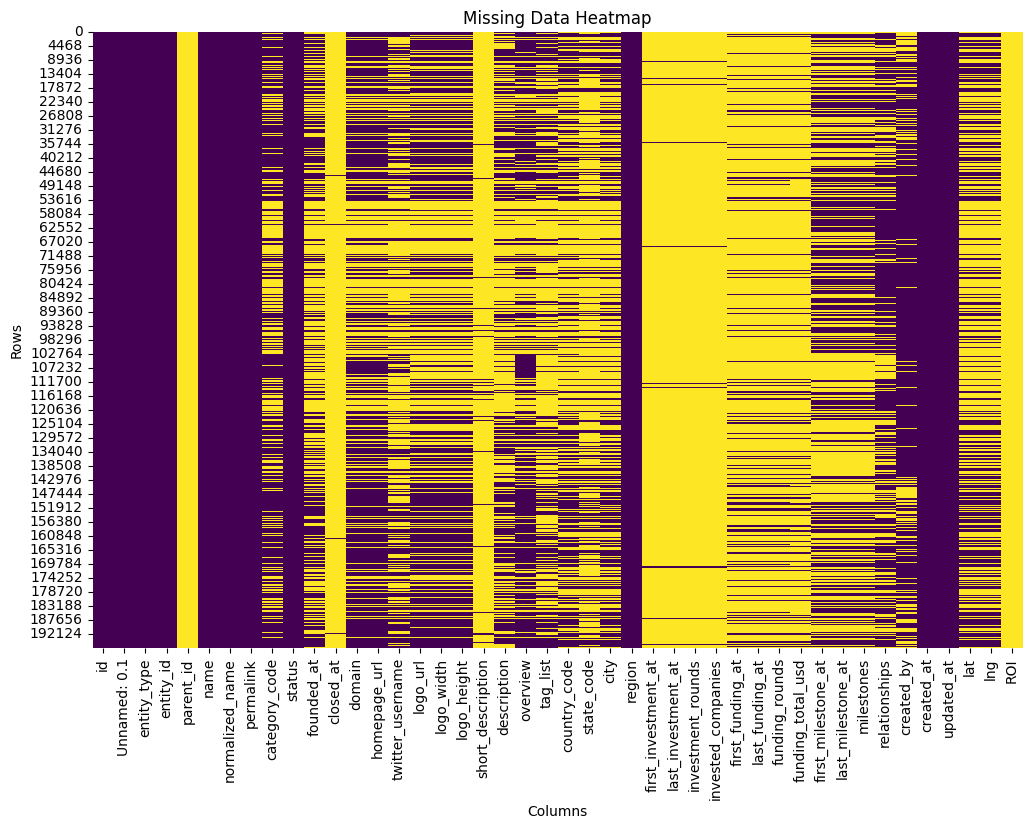

In [9]:
import matplotlib.pyplot as plt
# Assuming 'data' is your DataFrame
plt.figure(figsize=(12, 8))  # Adjust the figure size as needed
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')

# sns.heatmap(...): This creates the heatmap.
'''data.isnull() means This generates a DataFrame of the same shape as data,
 with True where the data is missing and False where it's not.'''
# cbar=False means Removes the color bar, which is not very useful in this context.
# cmap='viridis' means Sets the color map. where we can choose different color maps like 'YlGnBu', 'coolwarm', etc.

plt.title('Missing Data Heatmap')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

###Understand the Distribution of Variables

array([[<Axes: title={'center': 'Unnamed: 0.1'}>,
        <Axes: title={'center': 'entity_id'}>,
        <Axes: title={'center': 'parent_id'}>,
        <Axes: title={'center': 'logo_width'}>],
       [<Axes: title={'center': 'logo_height'}>,
        <Axes: title={'center': 'investment_rounds'}>,
        <Axes: title={'center': 'invested_companies'}>,
        <Axes: title={'center': 'funding_rounds'}>],
       [<Axes: title={'center': 'funding_total_usd'}>,
        <Axes: title={'center': 'milestones'}>,
        <Axes: title={'center': 'relationships'}>,
        <Axes: title={'center': 'lat'}>],
       [<Axes: title={'center': 'lng'}>, <Axes: title={'center': 'ROI'}>,
        <Axes: >, <Axes: >]], dtype=object)

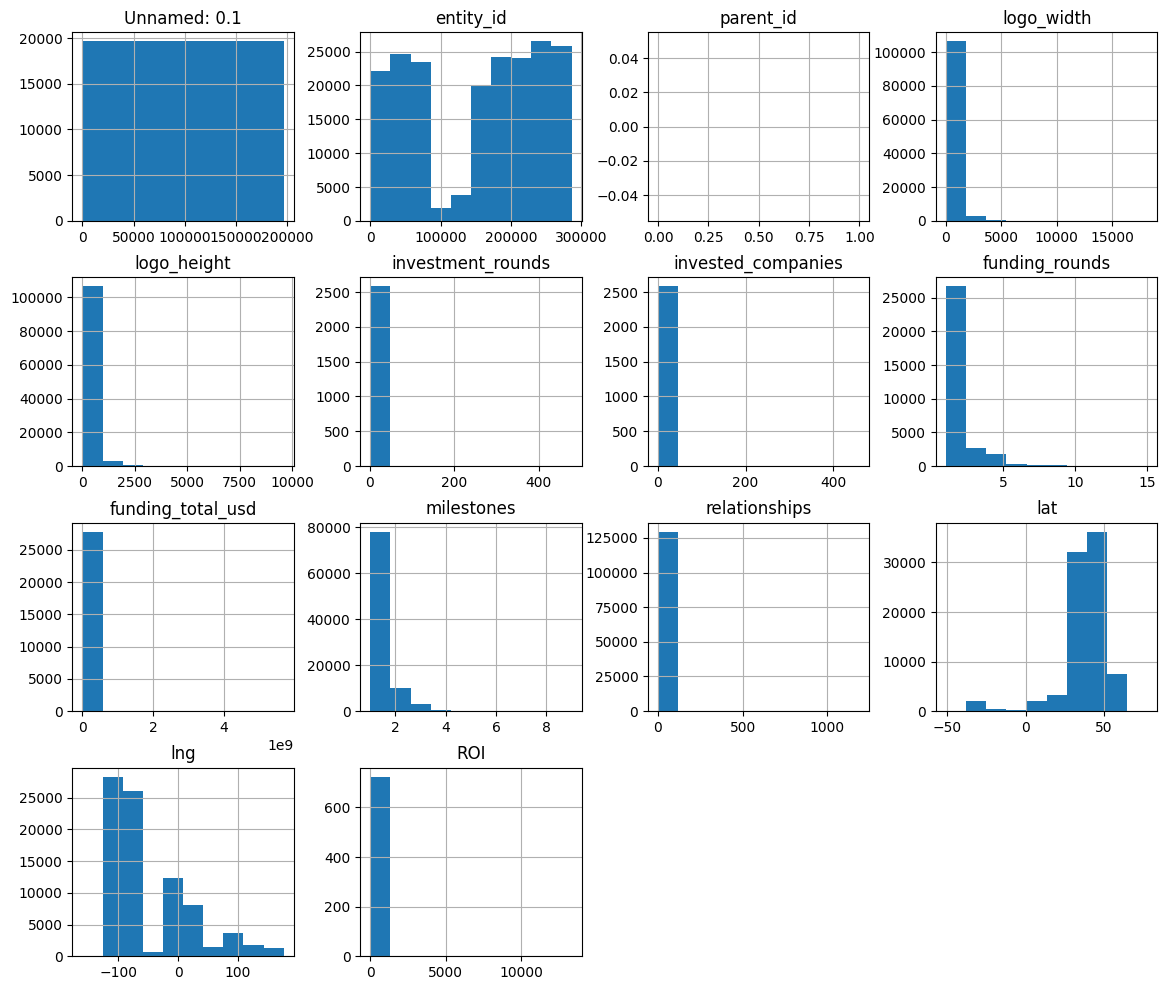

In [10]:
# view the distribution of numerical variables
data.hist(figsize=(14, 12))

In [11]:
print(data.columns)

Index(['id', 'Unnamed: 0.1', 'entity_type', 'entity_id', 'parent_id', 'name',
       'normalized_name', 'permalink', 'category_code', 'status', 'founded_at',
       'closed_at', 'domain', 'homepage_url', 'twitter_username', 'logo_url',
       'logo_width', 'logo_height', 'short_description', 'description',
       'overview', 'tag_list', 'country_code', 'state_code', 'city', 'region',
       'first_investment_at', 'last_investment_at', 'investment_rounds',
       'invested_companies', 'first_funding_at', 'last_funding_at',
       'funding_rounds', 'funding_total_usd', 'first_milestone_at',
       'last_milestone_at', 'milestones', 'relationships', 'created_by',
       'created_at', 'updated_at', 'lat', 'lng', 'ROI'],
      dtype='object')


In [12]:
data['twitter_username'].value_counts() # see the frequency of each category.

,count
twitter_username,
Goodman_UK,20
IndiaMART,17
localnomad,8
RamsayHealth,8
careysessoms,7
...,...
IcreonUK,1
Concurrent,1
alogocorp,1


###Explore Relationships Between Variables

In [13]:
data.dtypes

,0
id,object
Unnamed: 0.1,int64
entity_type,object
entity_id,int64
parent_id,float64
name,object
normalized_name,object
permalink,object
category_code,object
status,object


In [14]:
'''calculate the correlation between numerical variables'''
# Filter out only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_data.corr()

# Display the correlation matrix
correlation_matrix


,Unnamed: 0.1,entity_id,parent_id,logo_width,logo_height,investment_rounds,invested_companies,funding_rounds,funding_total_usd,milestones,relationships,lat,lng,ROI
Unnamed: 0.1,1.000000,-0.269074,NaN,-0.050397,-0.065973,0.018964,0.019659,0.019632,0.014612,0.090653,0.030060,0.022726,-0.030353,0.004060
entity_id,-0.269074,1.000000,NaN,0.073013,0.127747,-0.079022,-0.073513,-0.256673,-0.113679,-0.370364,-0.158604,-0.045110,0.068573,0.185568
parent_id,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
logo_width,-0.050397,0.073013,NaN,1.000000,0.784554,0.043238,0.045034,0.002109,-0.029624,-0.013658,-0.010923,0.003374,0.016735,-0.017856
logo_height,-0.065973,0.127747,NaN,0.784554,1.000000,0.038305,0.039700,-0.018093,-0.034114,-0.039517,-0.020499,-0.008900,0.033913,-0.016878
investment_rounds,0.018964,-0.079022,NaN,0.043238,0.038305,1.000000,0.998337,0.024396,-0.028161,0.177141,0.108258,0.000087,-0.050258,-0.153856
invested_companies,0.019659,-0.073513,NaN,0.045034,0.039700,0.998337,1.000000,0.024320,-0.029237,0.165864,0.096963,-0.000246,-0.045647,-0.141322
funding_rounds,0.019632,-0.256673,NaN,0.002109,-0.018093,0.024396,0.024320,1.000000,0.247538,0.301662,0.206828,0.009679,-0.129863,-0.054402
funding_total_usd,0.014612,-0.113679,NaN,-0.029624,-0.034114,-0.028161,-0.029237,0.247538,1.000000,0.132476,0.189499,-0.004019,-0.027673,-0.035738
milestones,0.090653,-0.370364,NaN,-0.013658,-0.039517,0.177141,0.165864,0.301662,0.132476,1.000000,0.281683,0.039993,-0.114848,-0.050463


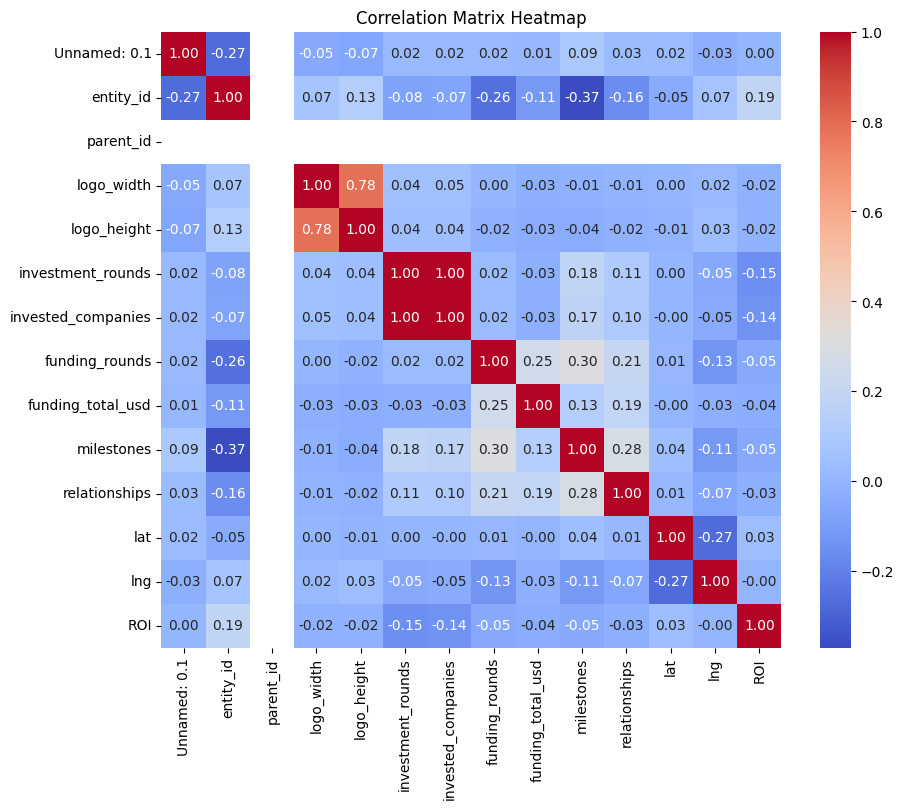

In [15]:
# visualize correlation_matrix with a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix Heatmap')
plt.show()

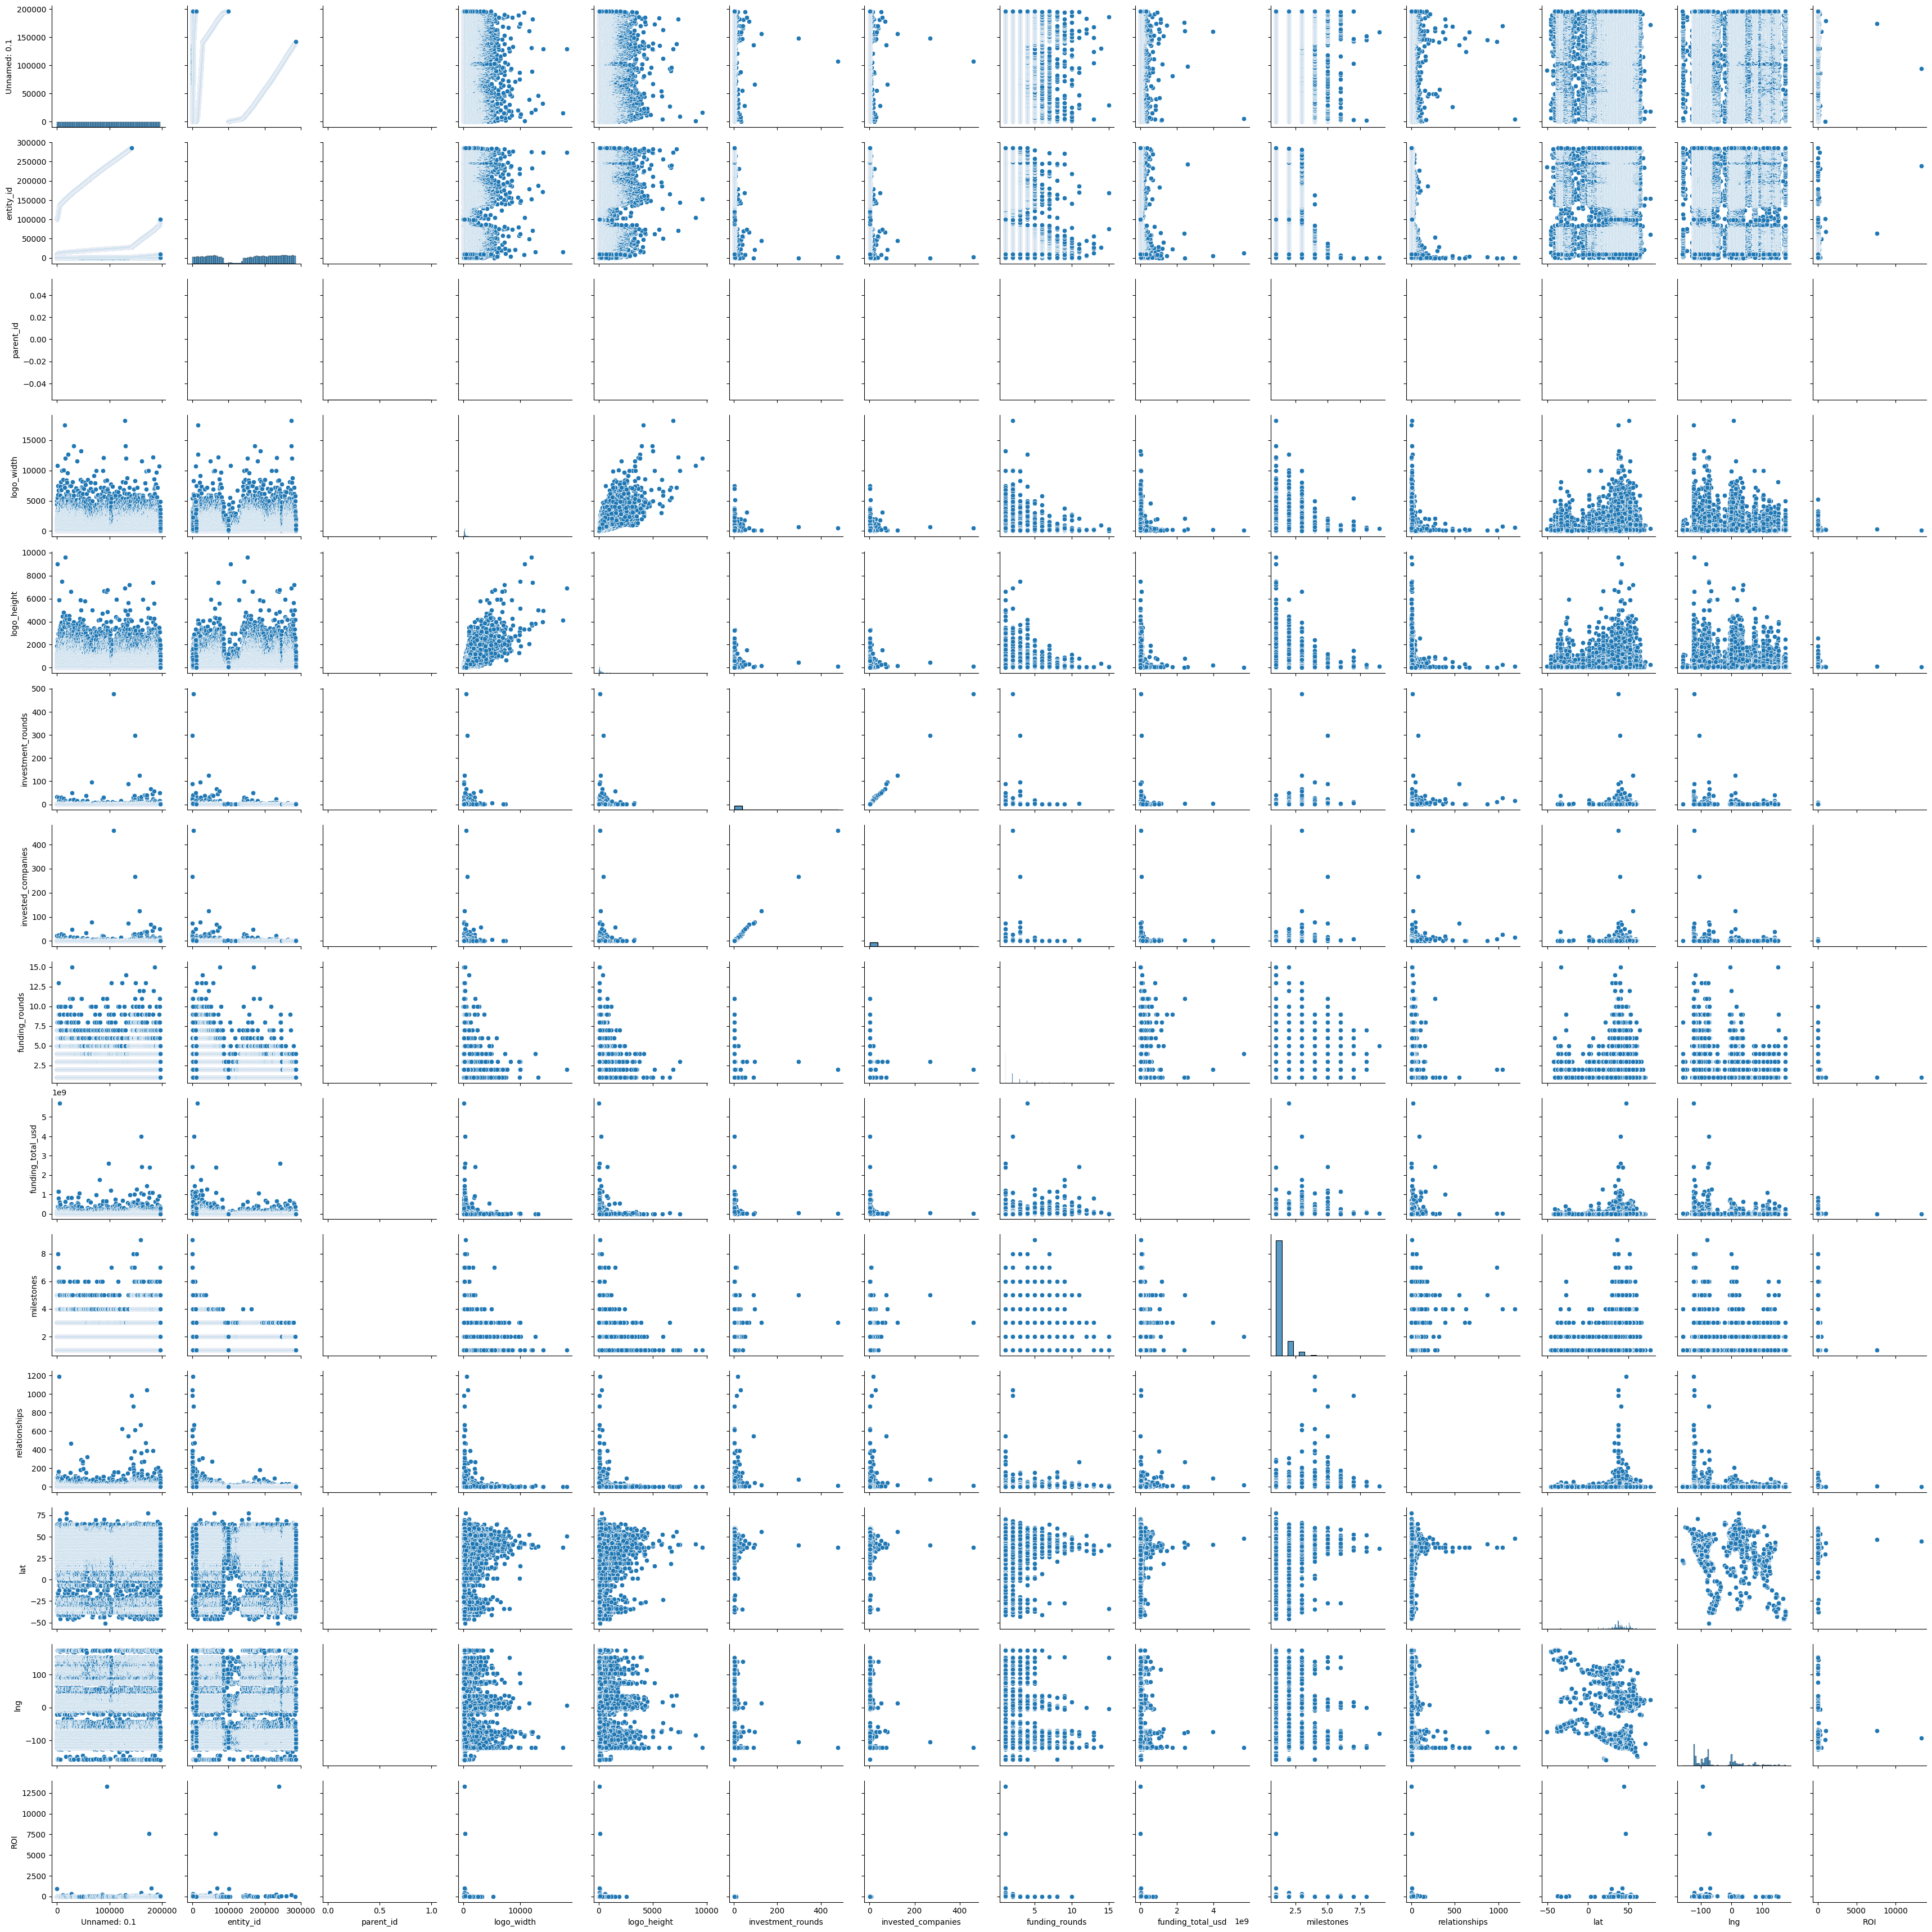

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# visualize relationships between multiple variables simultaneously.
sns.pairplot(data)

plt.show()


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


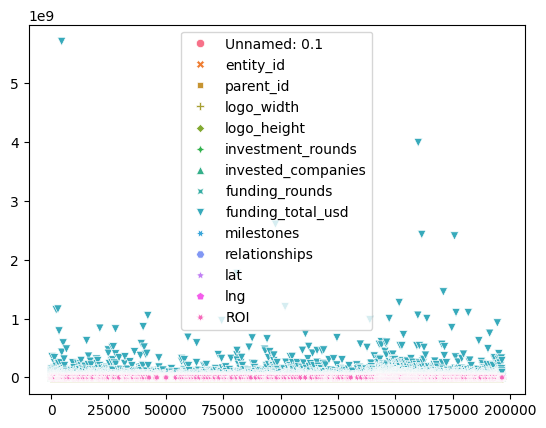

In [17]:
sns.scatterplot(data) # Visualizing relationships between two numerical variables.
plt.show()

###Here check for Data Imbalances in data processing

In [18]:
data['twitter_username'].value_counts()

,count
twitter_username,
Goodman_UK,20
IndiaMART,17
localnomad,8
RamsayHealth,8
careysessoms,7
...,...
IcreonUK,1
Concurrent,1
alogocorp,1


In [19]:
# Group Analysis: Compare summary statistics across different groups
numeric_data = data.select_dtypes(include=['number'])

# Assuming 'twitter_username' is the column you want to group by
mean_values = numeric_data.groupby(data['twitter_username']).mean()
mean_values

,Unnamed: 0.1,entity_id,parent_id,logo_width,logo_height,investment_rounds,invested_companies,funding_rounds,funding_total_usd,milestones,relationships,lat,lng,ROI
twitter_username,,,,,,,,,,,,,,
01communique,160998.0,49434.0,NaN,228.0,149.0,NaN,NaN,NaN,NaN,1.0,1.0,43.589045,-79.644120,NaN
040hosting,164997.0,53541.0,NaN,280.0,48.0,NaN,NaN,NaN,NaN,1.0,NaN,51.441642,5.469722,NaN
077football,86000.0,230930.0,NaN,720.0,540.0,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN
088088000100,136111.0,280364.0,NaN,200.0,184.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
0com_info,101924.0,246868.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zyrion,162589.0,51068.0,NaN,190.0,70.0,NaN,NaN,NaN,NaN,1.0,1.0,37.368830,-122.036350,NaN
zyrra_bras,175645.0,64173.0,NaN,195.0,116.0,NaN,NaN,3.0,1460500.0,NaN,1.0,52.205337,0.121817,NaN
zyxelindia,144709.0,31826.0,NaN,168.0,70.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


###Outlier Detection:
####for a Single Column

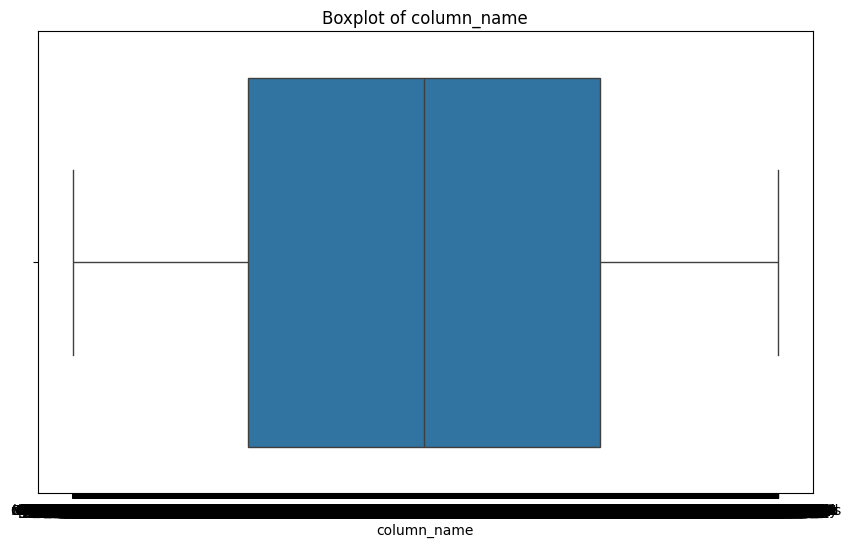

In [20]:
# Assuming 'twitter_username' is the column i want to visualize
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['twitter_username'])

plt.title('Boxplot of column_name')
plt.xlabel('column_name')
plt.show()


####Example for Multiple Columns:

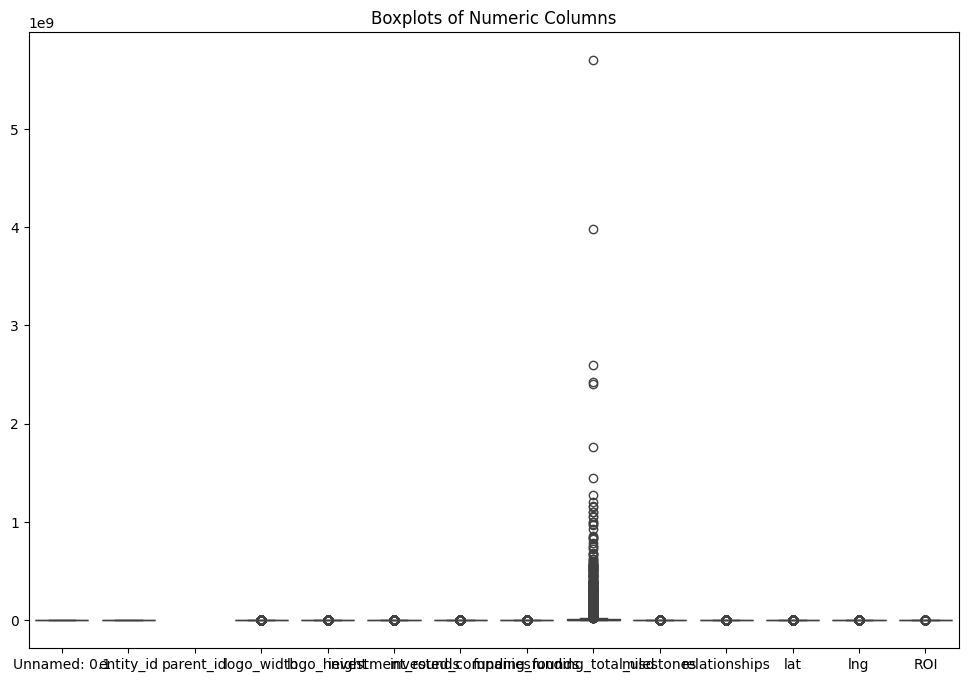

In [21]:
# Creating boxplots for all numeric columns
plt.figure(figsize=(12, 8))
sns.boxplot(data=data.select_dtypes(include=['number']))

plt.title('Boxplots of Numeric Columns')
plt.show()


In [22]:
data.columns

Index(['id', 'Unnamed: 0.1', 'entity_type', 'entity_id', 'parent_id', 'name',
       'normalized_name', 'permalink', 'category_code', 'status', 'founded_at',
       'closed_at', 'domain', 'homepage_url', 'twitter_username', 'logo_url',
       'logo_width', 'logo_height', 'short_description', 'description',
       'overview', 'tag_list', 'country_code', 'state_code', 'city', 'region',
       'first_investment_at', 'last_investment_at', 'investment_rounds',
       'invested_companies', 'first_funding_at', 'last_funding_at',
       'funding_rounds', 'funding_total_usd', 'first_milestone_at',
       'last_milestone_at', 'milestones', 'relationships', 'created_by',
       'created_at', 'updated_at', 'lat', 'lng', 'ROI'],
      dtype='object')

####Example with Grouping (Categorical and Numeric):

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 146 (\x92) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 154 (\x9a) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 150 (\x96) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


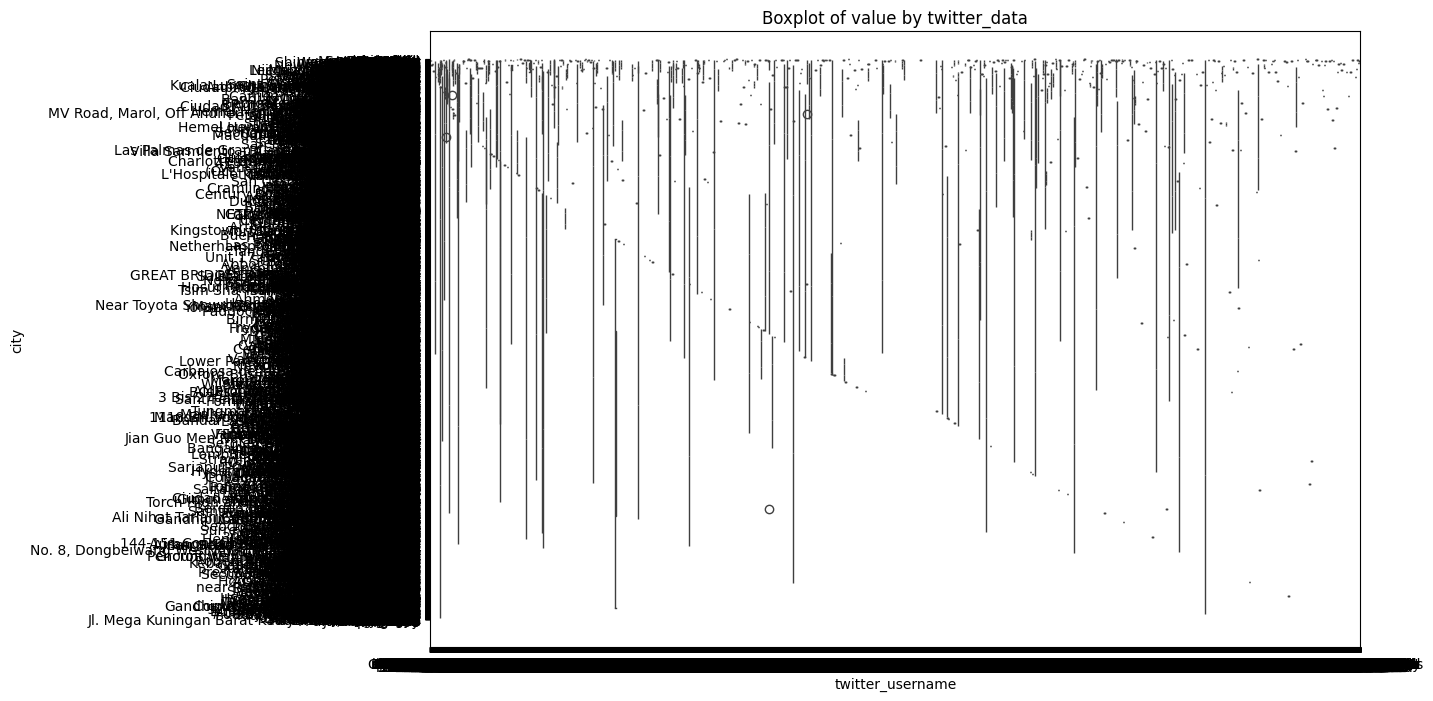

In [24]:
# Assuming 'relationships' is the categorical column and 'value' is the numeric column
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.boxplot(x='twitter_username', y='city', data=data)

plt.title('Boxplot of value by twitter_data')
plt.xlabel('twitter_username')
plt.ylabel('city')
plt.show()

#2.Data Cleaning
  1.Handling Missing Data



*   Identify missing values









In [25]:
data.isnull().sum() #identify missing values.

,0
id,0
Unnamed: 0.1,0
entity_type,0
entity_id,0
parent_id,196553
name,23
normalized_name,26
permalink,0
category_code,73367
status,0




*   Remove Rows/Columns with Missing Data



In [26]:
data.dropna(axis=0, inplace=True)  # Drop rows with missing values
data.dropna(axis=1, inplace=True)  # Drop columns with missing values




*   Impute Missing Values:
    *   Fill missing values with mean, median, mode, or a specific value.







In [27]:
data['twitter_username'].fillna(data['twitter_username'].mean(), inplace=True)
data['twitter_username'].fillna(data['twitter_username'].median(), inplace=True)
data['twitter_username'].fillna('Unknown', inplace=True)


In [28]:
# Replace incorrect values manually or using regex.
data['twitter_username'] = data['twitter_username'].replace('errored_value', 'correct_value')


In [29]:
# Identify and remove duplicate rows.
data.drop_duplicates(inplace=True)


,id,Unnamed: 0.1,entity_type,entity_id,parent_id,name,normalized_name,permalink,category_code,status,...,first_milestone_at,last_milestone_at,milestones,relationships,created_by,created_at,updated_at,lat,lng,ROI


In [30]:
# Example using Z-score
from scipy import stats
data = data[(np.abs(stats.zscore(data['twitter_username'])) < 3)]


In [31]:
import numpy as np

# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = data['twitter_username'].quantile(0.25)
Q3 = data['twitter_username'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define the upper and lower limits for capping
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q1 - 1.5 * IQR

# Capping the outliers
data['twitter_username'] = np.where(data['twitter_username'] > upper_limit, upper_limit, data['twitter_username'])
data['twitter_username'] = np.where(data['twitter_username'] < lower_limit, lower_limit, data['twitter_username'])

# Check the result
print(data['twitter_username'].describe())



count       0
unique      0
top       NaN
freq      NaN
Name: twitter_username, dtype: object


In [32]:
# Drop columns that are irrelevant or redundant for the analysis.
data.drop(['region'], axis=1, inplace=True)


In [33]:
data['twitter_username'] = data['twitter_username'].astype('float')
data['city'] = data['city'].astype('category')


In [34]:
def clean_column(column):
    # Convert all entries to string type
    column = column.astype(str)

    # Remove leading/trailing whitespace
    column = column.str.strip()

    # Convert to lowercase
    column = column.str.lower()

    return column

# Apply the function to the 'twitter_username' column
data['cleaned_column'] = clean_column(data['twitter_username'])

# Check the result
print(data['cleaned_column'].head())


Series([], Name: cleaned_column, dtype: object)


In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 44 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   id                   0 non-null      object  
 1   Unnamed: 0.1         0 non-null      int64   
 2   entity_type          0 non-null      object  
 3   entity_id            0 non-null      int64   
 4   parent_id            0 non-null      float64 
 5   name                 0 non-null      object  
 6   normalized_name      0 non-null      object  
 7   permalink            0 non-null      object  
 8   category_code        0 non-null      object  
 9   status               0 non-null      object  
 10  founded_at           0 non-null      object  
 11  closed_at            0 non-null      object  
 12  domain               0 non-null      object  
 13  homepage_url         0 non-null      object  
 14  twitter_username     0 non-null      float64 
 15  logo_url             0 non-null      obj

In [36]:
data.describe()

,Unnamed: 0.1,entity_id,parent_id,twitter_username,logo_width,logo_height,investment_rounds,invested_companies,funding_rounds,funding_total_usd,milestones,relationships,lat,lng,ROI
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#3. Data Encoding



In [69]:
company_names = data['name'].unique()
print(company_names)

['Wetpaint' 'Flektor' 'There' ... 'CSC' 'Top-candidate' 'Closet Couture']


In [70]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import category_encoders as ce

# Sample DataFrame
data = {
    'Company': ['Wetpaint', 'Flektor', 'There', 'CSC', 'Top-candidate', 'Closet Couture'],
    'Department': ['HR', 'Finance', 'IT', 'IT', 'HR', 'Finance'],
    'Performance': ['Good', 'Average', 'Excellent', 'Good', 'Average', 'Good'],
    'Salary': [70000, 80000, 120000, 70000, 80000, 100000]
}
df = pd.DataFrame(data)

# Label Encoding
label_encoder = LabelEncoder()
df['Performance_encoded'] = label_encoder.fit_transform(df['Performance'])

# One-Hot Encoding
df_one_hot = pd.get_dummies(df, columns=['Company', 'Department'])

# Binary Encoding
binary_encoder = ce.BinaryEncoder(cols=['Company', 'Department'])
df_binary_encoded = binary_encoder.fit_transform(df)

# Frequency Encoding
frequency_encoding = df['Department'].value_counts().to_dict()
df['Department_encoded'] = df['Department'].map(frequency_encoding)

# Target Encoding
mean_salary = df.groupby('Department')['Salary'].mean()
df['Department_target_encoded'] = df['Department'].map(mean_salary)

# Display results
print("Original DataFrame:")
print(df)
print("\nOne-Hot Encoded DataFrame:")
print(df_one_hot)
print("\nBinary Encoded DataFrame:")
print(df_binary_encoded)
print("\nFrequency Encoded DataFrame:")
print(df[['Department', 'Department_encoded']])
print("\nTarget Encoded DataFrame:")
print(df[['Department', 'Department_target_encoded']])


Original DataFrame:
          Company Department Performance  Salary  Performance_encoded  \
0        Wetpaint         HR        Good   70000                    2   
1         Flektor    Finance     Average   80000                    0   
2           There         IT   Excellent  120000                    1   
3             CSC         IT        Good   70000                    2   
4   Top-candidate         HR     Average   80000                    0   
5  Closet Couture    Finance        Good  100000                    2   

   Department_encoded  Department_target_encoded  
0                   2                    75000.0  
1                   2                    90000.0  
2                   2                    95000.0  
3                   2                    95000.0  
4                   2                    75000.0  
5                   2                    90000.0  

One-Hot Encoded DataFrame:
  Performance  Salary  Performance_encoded  Company_CSC  \
0        Good   70000   

#4. Data Labelling.


In [91]:
data.head()

,id,Unnamed: 0.1,entity_type,entity_id,parent_id,name,normalized_name,permalink,category_code,status,...,milestones,relationships,created_by,created_at,updated_at,lat,lng,ROI,Company_Status_Label,Company_Type
0,c:1,0,Company,1,NaN,Wetpaint,wetpaint,/company/wetpaint,web,operating,...,5.0,17.0,initial-importer,2007-05-25 06:51:27,2013-04-13 03:29:00,47.606209,-122.332071,15.5,Active - Technology,Technology
1,c:10,1,Company,10,NaN,Flektor,flektor,/company/flektor,games_video,acquired,...,NaN,6.0,initial-importer,2007-05-31 21:11:51,2008-05-23 23:23:14,34.021122,-118.396467,NaN,Acquired - Entertainment,Entertainment
2,c:100,2,Company,100,NaN,There,there,/company/there,games_video,acquired,...,4.0,12.0,initial-importer,2007-08-06 23:52:45,2013-11-04 02:09:48,37.562992,-122.325525,NaN,Acquired - Entertainment,Entertainment
3,c:10000,3,Company,10000,NaN,MYWEBBO,mywebbo,/company/mywebbo,network_hosting,operating,...,NaN,NaN,NaN,2008-08-24 16:51:57,2008-09-06 14:19:18,NaN,NaN,NaN,Active - Technology,Technology
4,c:10001,4,Company,10001,NaN,THE Movie Streamer,the movie streamer,/company/the-movie-streamer,games_video,operating,...,NaN,NaN,NaN,2008-08-24 17:10:34,2008-09-06 14:19:18,NaN,NaN,NaN,Active - Entertainment,Entertainment


###Now apply the Labeling Function

In [92]:
import pandas as pd

# Sample DataFrame
data = {
    'id': ['c:1', 'c:10', 'c:100', 'c:10000', 'c:10001'],
    'entity_type': ['Company', 'Company', 'Company', 'Company', 'Company'],
    'category_code': ['web', 'games_video', 'games_video', 'network_hosting', 'games_video']
}

df = pd.DataFrame(data)

# Define a function to label companies based on `category_code`
def label_company_type(category_code):
    if category_code in ['web', 'network_hosting']:
        return 'Technology'
    elif category_code in ['games_video']:
        return 'Entertainment'
    else:
        return 'Other'

# Apply the function to create a new column
df['Company_Type'] = df['category_code'].apply(label_company_type)

# Display the updated DataFrame
print(df)


        id entity_type    category_code   Company_Type
0      c:1     Company              web     Technology
1     c:10     Company      games_video  Entertainment
2    c:100     Company      games_video  Entertainment
3  c:10000     Company  network_hosting     Technology
4  c:10001     Company      games_video  Entertainment


###Handling Missing Data

In [93]:
# Check for missing values in the relevant column
print(df['category_code'].isnull().sum())

# Fill missing values or handle them as appropriate
df['category_code'].fillna('Unknown', inplace=True)

# Apply the labeling function after handling missing values
df['Company_Type'] = df['category_code'].apply(label_company_type)


0


In [99]:
df.head()

,id,entity_type,category_code,Company_Type
0,c:1,Company,web,Technology
1,c:10,Company,games_video,Entertainment
2,c:100,Company,games_video,Entertainment
3,c:10000,Company,network_hosting,Technology
4,c:10001,Company,games_video,Entertainment


from matplotlib import pyplot as plt
import seaborn as sns
_df_18.groupby('id').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_19.groupby('category_code').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_20.groupby('Company_Type').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['category_code'].value_counts()
    for x_label, grp in _df_21.groupby('id')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('id')
_ = plt.ylabel('category_code')

from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Company_Type'].value_counts()
    for x_label, grp in _df_22.groupby('category_code')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('category_code')
_ = plt.ylabel('Company_Type')

In [101]:
def label_company_status(Company_Type, category_code):
    if Company_Type == 'Entertainment':
        return 'Active - ' + label_company_type(category_code)
    elif Company_Type == 'Technology':
        return 'Acquired - ' + label_company_type(category_code)
    else:
        return 'Inactive - ' + label_company_type(category_code)

# Apply the advanced labeling function
df['Company_Status_Label'] = df.apply(lambda row: label_company_status(row['Company_Type'], row['category_code']), axis=1)

# Display the updated DataFrame
print(df)


        id entity_type    category_code   Company_Type    Company_Status_Label
0      c:1     Company              web     Technology   Acquired - Technology
1     c:10     Company      games_video  Entertainment  Active - Entertainment
2    c:100     Company      games_video  Entertainment  Active - Entertainment
3  c:10000     Company  network_hosting     Technology   Acquired - Technology
4  c:10001     Company      games_video  Entertainment  Active - Entertainment
